# Landslide Distribution

In [ ]:
import pip
pip.main(['install','matplotlib-scalebar'])

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sbn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
import pysal

import warnings
warnings.filterwarnings("ignore")

In [2]:
from pointpats import centrography
import libpysal
from pointpats import distance_statistics, QStatistic, random, PointPattern
from shapely.ops import cascaded_union
from shapely.geometry import Polygon

Se importa poligono de la cuenca

,fid,Area_Km2,Perime_Km,_mean,_min,_max,_range,_mean_1,_min_1,_max_1,codigo,Indices_ma,Indices__1,geometry
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,"POLYGON ((456805.063 868201.875, 456805.063 86..."


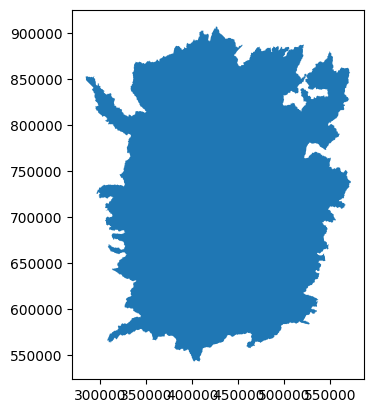

In [3]:
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot()
aoi.head()

,OBJECTID,Tipo,NombreFall,Autor(es),Autor,Geoformas,Activa,Mvto,Movimiento,geometry
0,15698,Falla cubierta,NaN,SGC (2018),NaN,NaN,NaN,NaN,NaN,"LINESTRING (346895.889 583004.600, 345858.935 ..."
1,15699,Falla cubierta,NaN,SGC (2018),NaN,NaN,NaN,NaN,NaN,"LINESTRING (342990.914 584006.363, 344387.655 ..."


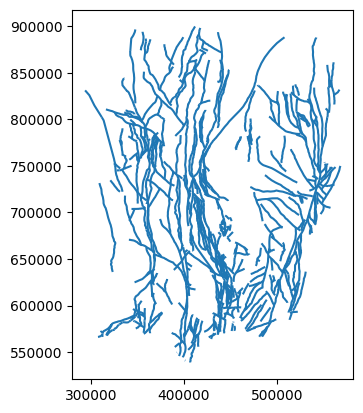

In [8]:
faults=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/fallas_autor_simbo.shp")
faults.plot()
faults.head(2)

## Recent landslides

Se importan lo movimientos en masa recientes que incluye el valor de lluvia media anual en la columna 'SAMPLE_1', el cual se elaboro en QGIS.

In [4]:
recent=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2.gpkg")
recent.head(2)

,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,date,source,geometry
0,NaN,NaN,NaT,NaT,NaT,NaN,-1,0,-1,NaN,NaN,09/2006,My Places — _Points_,POINT Z (439722.005 681812.005 0.000)
1,NaN,NaN,NaT,NaT,NaT,NaN,-1,0,-1,NaN,NaN,09/2011,My Places — _Points_,POINT Z (437541.797 675246.253 0.000)


Se eliminan las columnas que nos e van a utilizar y se cambia el nombre de la columna que tiene la lluvia. Y se proyecta a coordenadas planas.

,date,source,geometry
0,09/2006,My Places — _Points_,POINT Z (439722.005 681812.005 0.000)
1,09/2011,My Places — _Points_,POINT Z (437541.797 675246.253 0.000)


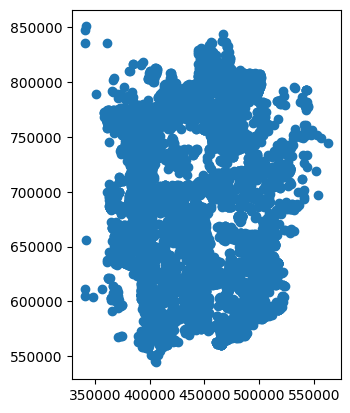

In [6]:
rec=recent.drop(["Name","description","timestamp","begin","end","altitudeMode","tessellate","extrude","visibility","drawOrder","icon"],axis=1)
rec.plot()
rec.head(2)

In [7]:
rec["x"]=rec.centroid.x
rec["y"]=rec.centroid.y
rec_coor = rec[['x','y']].values

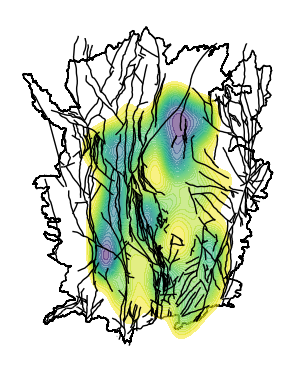

In [9]:
f, ax = plt.subplots()
aoi.plot(ax=ax, facecolor="none")
faults.plot(ax=ax,edgecolor='black',linestyle='-',linewidth=1)
sbn.kdeplot(x=rec['x'],y=rec['y'],n_levels=30,fill=True,alpha=0.55,cmap='viridis_r')
ax.set_axis_off()

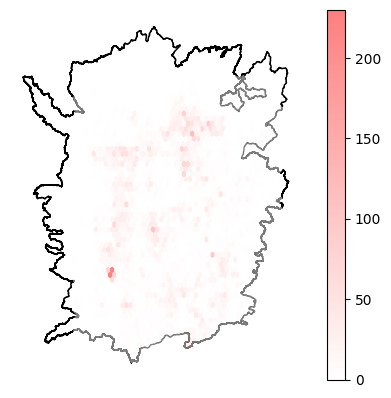

In [10]:
f, ax = plt.subplots()
aoi.plot(ax=ax, facecolor="none")
c_white = matplotlib.colors.colorConverter.to_rgba('white',alpha = 0)
c_red= matplotlib.colors.colorConverter.to_rgba('red',alpha = 1)
cmap_rb = matplotlib.colors.LinearSegmentedColormap.from_list('rb_cmap',[c_white,c_red],512)    
hb = ax.hexbin(rec['x'],rec['y'],gridsize=50,linewidths=0,alpha=0.5,cmap=cmap_rb)
plt.colorbar(hb)
ax.set_axis_off()

In [11]:
convex_hull_rec = centrography.hull(rec_coor)
alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(rec_coor, return_circles=True)

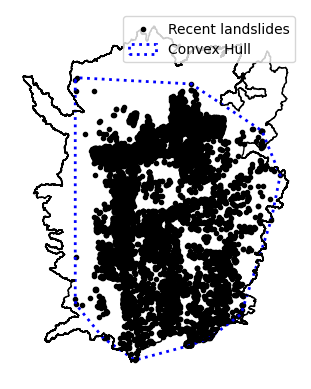

In [12]:
f,ax = plt.subplots(1,1)

# Include the points for our prolific user in black
ax.scatter(*rec_coor.T, color='k', marker='.', label='Recent landslides')

# add a blue convex hull
ax.add_patch(plt.Polygon(convex_hull_rec,closed=True,edgecolor='blue',facecolor='none',linestyle=':',linewidth=2,label='Convex Hull'))
aoi.plot(ax=ax, facecolor="none")
plt.legend();
ax.set_axis_off()

<Axes: title={'center': 'Quadrat Count'}>

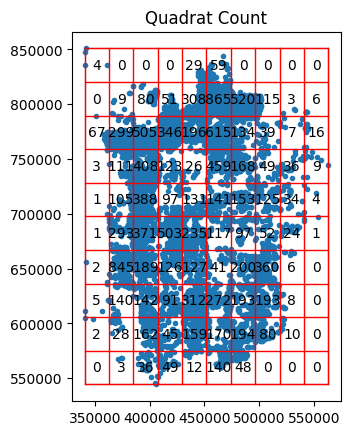

In [13]:
qstat = QStatistic(rec_coor, nx = 10, ny = 10)
qstat.plot()

chi-squared test compares how likely this distribution is if the cell counts are uniform. A very small p-value means statistically significant. In other words, p-high values represent a uniform distribution.

In [14]:
qstat.chi2

23342.1577970297

In [15]:
qstat.chi2_pvalue

0.0

In [16]:
qstat.df

99

Since the p-value based on the analytical  χ2  distribution (degree of freedom 99.8) is 0.0, much smaller than 0.05. We might determine that the underlying process is not CSR. We can also turn to empirical sampling distribution to ascertain our decision.

The Ripley's $G$ function focuses on the distribution of nearest neighbor distances. That is, the $G$ function summarises the distances between each point in the pattern and their nearest neighbor. Ripley's $G$ keeps track of the proportion of points for which the nearest neighbor is within a given distance threshold, and plots that cumulative percentage against the increasing distance radiuses. The distribution of these cumulative percentage has a distinctive shape under completely spatially random processes. The intuition behind Ripley's G goes as follows: we can learn about how similar our pattern is to a spatially random one by computing the cumulative distribution of nearest neighbor distances over increasing distance thresholds, and comparing it to that of a set of simulated patterns that follow a known spatially-random process. Usually, a spatial Poisson point process is used as such reference distribution. 

The `pointpats` package use the `g_test` function, which computes both the `G` function for the empirical data *and* these hypothetical replications under a completely spatially random process.

## Relict landslides

,rainfall,geometry
0,1841.776395,POINT Z (404187.110 752665.590 753.108)
1,1946.703969,POINT Z (443782.345 703321.444 1592.606)


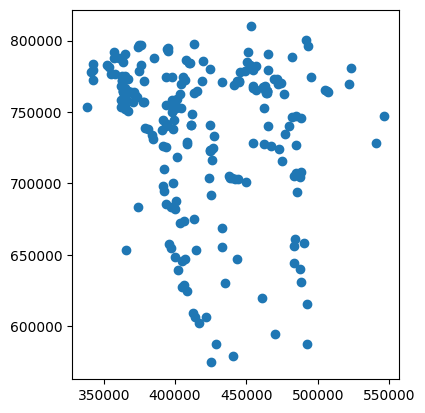

In [34]:
relict=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_rainfall.gpkg")
rel=relict.drop(["Name","descriptio","timestamp","begin","end","altitudeMo","tessellate","extrude","visibility","drawOrder","icon"],axis=1)
rel.rename(columns={"SAMPLE_1":"rainfall"}, inplace=True)
rel=rel.to_crs(epsg=32618)
rel.plot()
rel.head(2)

In [35]:
rel["x"]=rel.centroid.x
rel["y"]=rel.centroid.y
rel_coor = rel[['x','y']].values

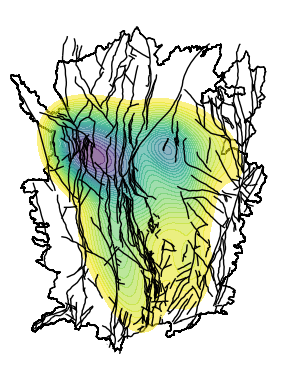

In [36]:
f, ax = plt.subplots()
aoi.plot(ax=ax, facecolor="none")
faults.plot(ax=ax,edgecolor='black',linestyle='-',linewidth=1)
sbn.kdeplot(x=rel['x'],y=rel['y'],n_levels=30,fill=True,alpha=0.55,cmap='viridis_r')
ax.set_axis_off()

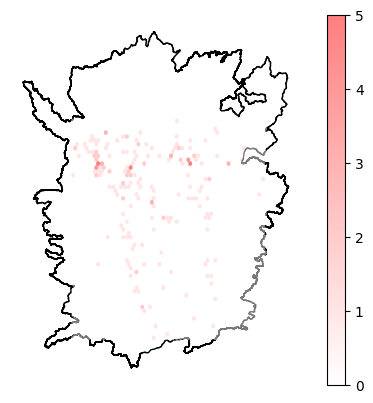

In [21]:
f, ax = plt.subplots()
aoi.plot(ax=ax, facecolor="none")
c_white = matplotlib.colors.colorConverter.to_rgba('white',alpha = 0)
c_red= matplotlib.colors.colorConverter.to_rgba('red',alpha = 1)
cmap_rb = matplotlib.colors.LinearSegmentedColormap.from_list('rb_cmap',[c_white,c_red],512)   
hb = ax.hexbin(rel['x'],rel['y'],gridsize=50,linewidths=0,alpha=0.5,cmap=cmap_rb)
plt.colorbar(hb)
ax.set_axis_off()

In [37]:
convex_hull_rel = centrography.hull(rel_coor)
alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(rel_coor, return_circles=True)

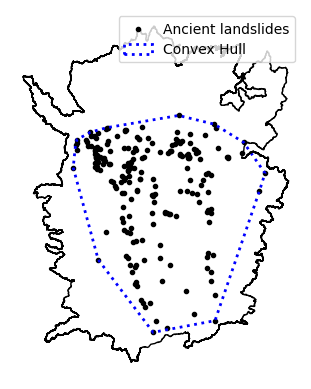

In [25]:
f,ax = plt.subplots(1,1)
ax.scatter(*rel_coor.T, color='k', marker='.', label='Ancient landslides')
# add a blue convex hull
ax.add_patch(plt.Polygon(convex_hull_rel,closed=True,edgecolor='blue',facecolor='none',linestyle=':',linewidth=2,label='Convex Hull'))
aoi.plot(ax=ax, facecolor="none")
plt.legend();
ax.set_axis_off()

<Axes: title={'center': 'Quadrat Count'}>

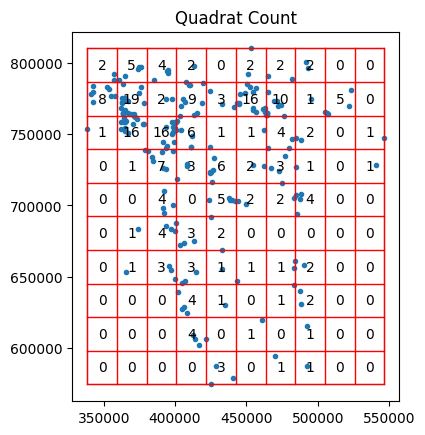

In [21]:
qstat = QStatistic(rel_coor, nx = 10, ny = 10)
qstat.plot()

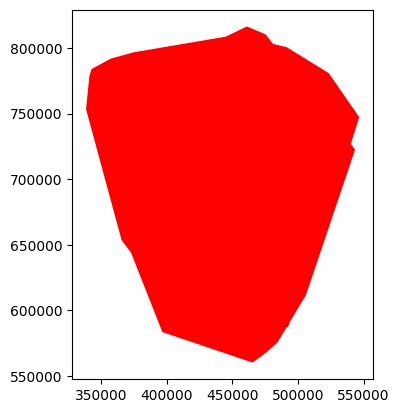

In [56]:
fig,ax=plt.subplots(1,1)
polygons = [Polygon(convex_hull_rel), Polygon(convex_hull_rec)]
hull = gpd.GeoSeries(cascaded_union(polygons))
hull.plot(ax=ax,color='red')
plt.show()

In [38]:
hull_coor=hull.get_coordinates().values

NameError: name 'hull' is not defined

## Density and faults

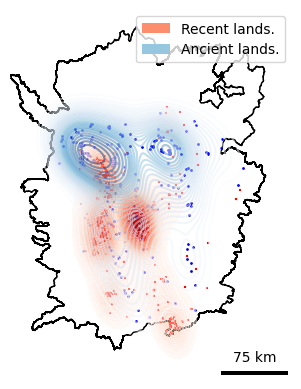

In [109]:
import matplotlib.patches as  mpatches
f, ax = plt.subplots()
aoi.plot(ax=ax, facecolor="none")
ax.scatter(*rel_coor.T, color='blue', marker='.',s=4)
ax.scatter(*rec_coor.T, color='red', marker='+',s=4)
#faults.plot(ax=ax,edgecolor='black',linestyle='-',linewidth=0.5)
sbn.kdeplot(x=rec['x'],y=rec['y'],n_levels=30,fill=True,alpha=0.5,cmap='Reds')
sbn.kdeplot(x=rel['x'],y=rel['y'],n_levels=30,fill=False,alpha=0.5,cmap='Blues')
scalebar = ScaleBar(1,"m", location="lower right", scale_loc="top", length_fraction=0.25)
handles = [mpatches.Patch(facecolor=plt.cm.Reds(100), label="Recent lands."),mpatches.Patch(facecolor=plt.cm.Blues(100), label="Ancient lands.")]
plt.legend(handles=handles)
ax.add_artist(scalebar)
ax.set_axis_off()
f.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/landslide_inventory_density.png",dpi=500)

In [39]:
g_rel = distance_statistics.g_test(rel_coor, support=40, keep_simulations=True)

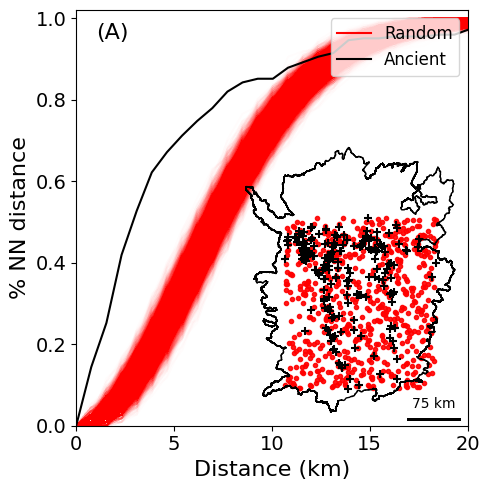

In [21]:
f,ax = plt.subplots(figsize=(5,5))
ax.plot(g_rel.support/1000, g_rel.simulations.T, color='red', alpha=.01)
ax.plot(g_rel.support/1000, np.median(g_rel.simulations, axis=0),label = 'Random',color='red')
ax.plot(g_rel.support/1000, g_rel.statistic, label = 'Ancient', color='black')
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_xlim(0,20)
ax.set_ylim(0,1.02)
ax.set_xlabel('Distance (km)', fontsize=16)
ax.set_ylabel('% NN distance', fontsize=16)
ax.legend(ncol=1, loc='upper right',prop={'size': 12})
ax.set_xticks(ax.get_xticks()[::1])
ax.text(1,0.95,'(A)',fontsize = 16, color ="black") 

random_pattern = random.poisson(rel_coor, size=len(rec_coor))

axin=ax.inset_axes([0.35,0.001,0.7,0.7])
axin.scatter(*random_pattern.T, color='r', marker='.', label='Random points', alpha=0.9)
axin.scatter(*rel_coor.T, color='k', marker='+', label='Ancient landslide')
#axin.legend(ncol=1, loc='upper left',prop={'size': 14})
aoi.plot(ax=axin, facecolor="none")
axin.set_axis_off()
scalebar = ScaleBar(1,"m", location="lower right", scale_loc="top", length_fraction=0.25)
axin.add_artist(scalebar)
f.tight_layout();
plt.show()
f.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/ancient_inventory_Ripley.png", dpi=500)

In [17]:
g_rec = distance_statistics.g_test(rec_coor, support=40, keep_simulations=True)

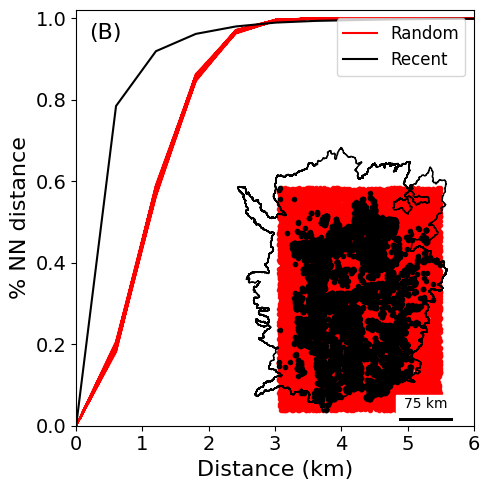

In [21]:
f,ax = plt.subplots(figsize=(5,5))
ax.plot(g_rec.support/1000, g_rec.simulations.T, color='red', alpha=.01)
ax.plot(g_rec.support/1000, np.median(g_rec.simulations, axis=0), color='red',label='Random')
ax.plot(g_rec.support/1000, g_rec.statistic, label = 'Recent', color='black')
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_xlim(0,6)
ax.set_ylim(0,1.02)
ax.set_xlabel('Distance (km)', fontsize=16)
ax.set_ylabel('% NN distance', fontsize=16)
ax.legend(ncol=1, loc='upper right',prop={'size': 12})
ax.set_xticks(ax.get_xticks()[::1])
ax.text(0.2,0.95,'(B)',fontsize = 16, color ="black") 


random_pattern = random.poisson(rec_coor, size=len(rec_coor))

axin=ax.inset_axes([0.32,0.001,0.7,0.7])
axin.scatter(*random_pattern.T, color='r', marker='.', label='Random points', alpha=0.9)
axin.scatter(*rec_coor.T, color='k', marker='.', label='Recent landslide')
#axin.legend(ncol=1, loc='upper left',prop={'size': 14})
aoi.plot(ax=axin, facecolor="none")
axin.set_axis_off()
scalebar = ScaleBar(1,"m", location="lower right", scale_loc="top", length_fraction=0.25)
axin.add_artist(scalebar)
f.tight_layout();
plt.show()
f.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/recent_inventory_Ripley.png", dpi=500)

## Ripley's

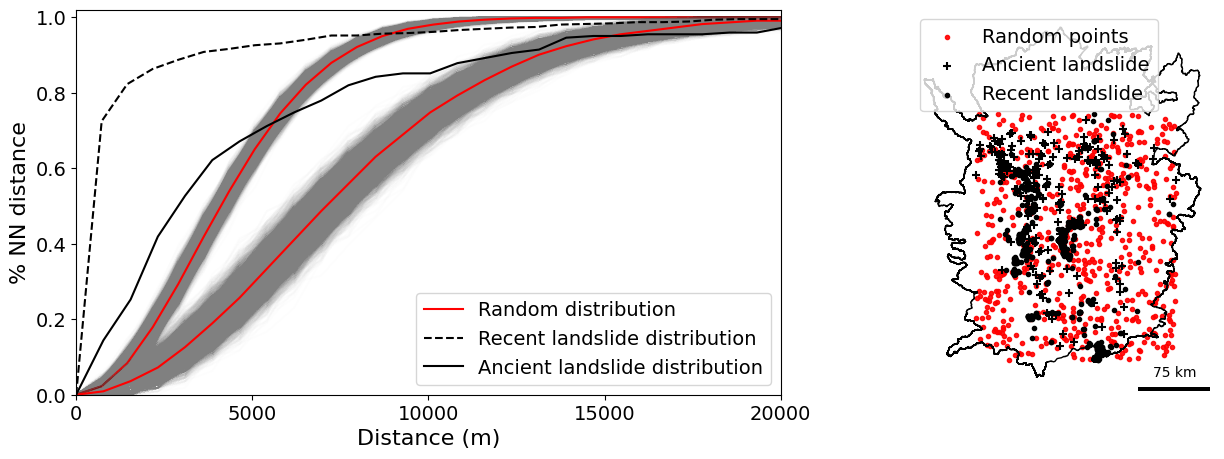

In [91]:
g_rec = distance_statistics.g_test(rec_coor, support=40, keep_simulations=True)
g_rel = distance_statistics.g_test(rel_coor, support=40, keep_simulations=True)

f,ax = plt.subplots(1,2,figsize=(15,5),gridspec_kw=dict(width_ratios=(6,3)))
# plot all the simulations with very fine lines
ax[0].plot(g_rec.support, g_rec.simulations.T, color='grey', alpha=.01)
ax[0].plot(g_rec.support, np.median(g_rec.simulations, axis=0), color='red',label='Random distribution')
ax[0].plot(g_rec.support, g_rec.statistic, label = 'Recent landslide distribution', color='black',linestyle='dashed')
ax[0].plot(g_rel.support, g_rel.simulations.T, color='grey', alpha=.01)
ax[0].plot(g_rel.support, np.median(g_rel.simulations, axis=0), color='red')
ax[0].plot(g_rel.support, g_rel.statistic, label = 'Ancient landslide distribution', color='black')
ax[0].xaxis.set_tick_params(labelsize=14)
ax[0].yaxis.set_tick_params(labelsize=14)
ax[0].set_xlim(0,20000)
ax[0].set_ylim(0,1.02)

# clean up labels and axes
ax[0].set_xlabel('Distance (m)', fontsize=16)
ax[0].set_ylabel('% NN distance', fontsize=16)
ax[0].legend(ncol=1, loc='lower right',prop={'size': 14})
ax[0].set_xticks(ax[0].get_xticks()[::2])
#ax[0].set_xlim(0,2000)
random_pattern = random.poisson(hull_coor, size=len(rec_coor))
ax[1].scatter(*random_pattern.T, color='r', marker='.', label='Random points', alpha=0.9)
ax[1].scatter(*rel_coor.T, color='k', marker='+', label='Ancient landslide')
ax[1].scatter(*rec_coor.T, color='k', marker='.', label='Recent landslide')
ax[1].legend(ncol=1, loc='upper left',prop={'size': 14})
aoi.plot(ax=ax[1], facecolor="none")
ax[1].set_axis_off()
scalebar = ScaleBar(1,"m", location="lower right", scale_loc="top", length_fraction=0.25)
ax[1].add_artist(scalebar)

plt.show()
f.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/landslide_inventory_Ripley2.png", dpi=500)

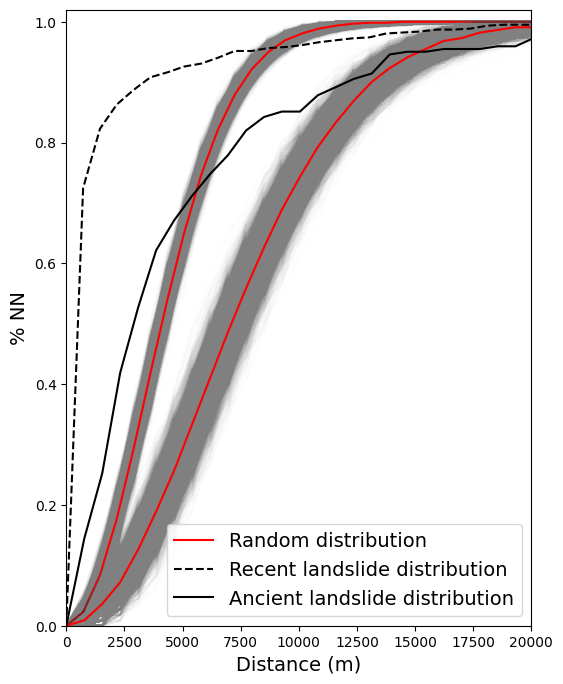

In [45]:
f,ax = plt.subplots(1,1,figsize=(6,8))
# plot all the simulations with very fine lines
ax.plot(g_rec.support, g_rec.simulations.T, color='grey', alpha=.01)
# and show the average of simulations
ax.plot(g_rec.support, np.median(g_rec.simulations, axis=0), color='red',label='Random distribution')
ax.plot(g_rel.support, g_rel.simulations.T, color='grey', alpha=.01)
# and show the average of simulations
ax.plot(g_rel.support, np.median(g_rel.simulations, axis=0), color='red')
# and the observed pattern's G function
ax.plot(g_rec.support, g_rec.statistic, label = 'Recent landslide distribution', color='black',linestyle='dashed')
ax.plot(g_rel.support, g_rel.statistic, label = 'Ancient landslide distribution', color='black')
ax.set_xlim(0,20000)
ax.set_ylim(0,1.02)
ax.set_xlabel('Distance (m)', fontsize=14)
ax.set_ylabel('% NN', fontsize=14)
ax.legend(ncol=1, loc='lower right',prop={'size': 14})
plt.show()
f.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/landslide_inventory_Ripley_B.png")

Where the $G$ function works by analyzing the distance *between* points in the pattern, the Ripley's $F$ function works by analyzing the distance *to* points in the pattern from locations in empty space. That is why the $F$ function is called the "the empty space function", since it characterizes the typical distance from arbitrary points in empty space to the point pattern. More explicitly, the $F$ accumulates, for a growing distance range, the percentage of points that can be found within that range from a random point pattern generated within the extent of the observed pattern. If the pattern has large gaps or empty areas, the $F$ function will increase slowly. But, if the pattern is highly dispersed, then the $F$ function will increase rapidly. The shape of this cumulative distribution is then compared to those constructed by calculating the same cumulative distribution between the random pattern and an additional, random one generated in each simulation step.

We can use similar tooling to investigate the $F$ function, since it is so mathematically similar to the $G$ function. This is implemented identically using the `f_test` function in `pointpats`. Since the $F$ function estimated for the observed pattern increases *much* more slowly than the $F$ functions for the simulated patterns, we can be confident that there are many gaps in our pattern; i.e. the pattern is *clustered*. 


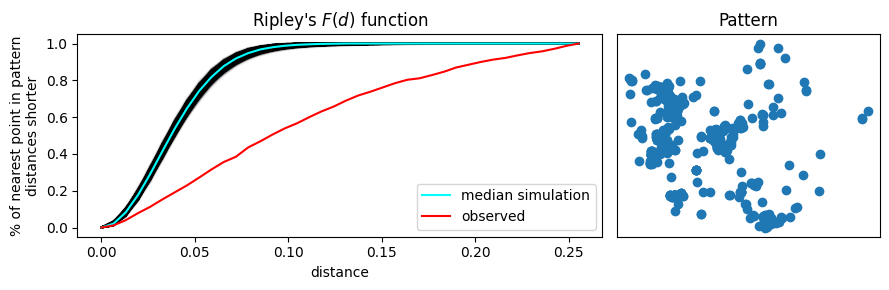

In [120]:
f_test = distance_statistics.f_test(coordinates, support=40, keep_simulations=True)

f,ax = plt.subplots(1,2,figsize=(9,3), gridspec_kw=dict(width_ratios=(6,3)))
# plot all the simulations with very fine lines
ax[0].plot(f_test.support, f_test.simulations.T, color='k', alpha=.01)
# and show the average of simulations
ax[0].plot(f_test.support, np.median(f_test.simulations, axis=0),color='cyan',label='median simulation')
# and the observed pattern's F function
ax[0].plot(f_test.support, f_test.statistic, label = 'observed', color='red')
# clean up labels and axes
ax[0].set_xlabel('distance')
ax[0].set_ylabel('% of nearest point in pattern\ndistances shorter')
ax[0].legend()
#ax[0].set_xlim(0,2000)

# plot the pattern itself on the next frame
ax[1].scatter(*coordinates.T)
# and clean up labels and axes there, too
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
f.tight_layout()
plt.show()